# Assignment 4 - Neuroscience

## Setup and Required Libraries

In [ ]:
# run this cell in case of a problem with the imports 
# %pip install pandas numpy torch torchaudio h5py soundfile spicy umap-learn seaborn

In [25]:
import numpy as np
import torch
from scipy.spatial.distance import pdist, squareform
from torch.utils.data import DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import umap

from core import SantoroDataset, MODEL_CLASSES, extract_activations, load_yamnet_activations
from config import CHECKPOINT_DIR, NUM_CLASSES, BATCH_SIZE

## Toolbox

In [37]:
def compute_rdm(patterns: np.ndarray) -> np.ndarray:
    """Compute the Euclidean-distance RDM for a set of representational patterns."""

    # Ensure we have np array and not torch tensor
    patterns = np.asarray(patterns)

    # Flatten into 1D data
    patterns = patterns.reshape(patterns.shape[0], -1)

    # Compute pairwise euclidean distances
    eucl_distances = pdist(patterns, metric='euclidean')

    # Convert distances into symmetric matrix
    return squareform(eucl_distances)


def upper_triangle(rdm: np.ndarray) -> np.ndarray:
    """Extract the off-diagonal upper-triangular entries of an RDM as a 1D vector."""

    # Get indices of the upper triangular values
    # We use k = 1 not to include 0s at the main diagonal
    row_indices, col_indices = np.triu_indices(n=rdm.shape[0], k=1)

    return rdm[row_indices, col_indices]


def compare_rdms(rdm_a: np.ndarray, rdm_b: np.ndarray) -> float:
    """Compare two RDMs via Pearson correlation of their upper-triangular entries."""

    # Get upper triangular values
    up_values_a = upper_triangle(rdm_a)
    up_values_b = upper_triangle(rdm_b)

    # Compute centered values
    centered_a = up_values_a - np.mean(up_values_a)
    centered_b = up_values_b - np.mean(up_values_b)

    numerator = np.sum(centered_a * centered_b)
    denominator = np.sqrt(np.sum(centered_a ** 2) * np.sum(centered_b ** 2))

    return numerator / denominator


def compute_layer_alignments(model_rdms: dict, target_rdm: np.ndarray) -> dict:
    """Compute mean and std RSA correlation with target_rdm for each layer across runs."""
    alignments = {}

    # Go through each model
    for model_name, runs in model_rdms.items():

        alignments[model_name] = {}

        # Get all layers
        layer_names = list(runs[0].keys())

        # Go through each layer
        for layer_name in layer_names:

            scores = []

            # Go through each run
            for run in runs:
                scores.append(compare_rdms(target_rdm, run[layer_name]))

            # Get average and std across runs per layer
            alignments[model_name][layer_name] = {
                "mean": float(np.mean(scores)),
                "std": float(np.std(scores)),
            }

    return alignments

def plot_embeddings(representations_dict, categories, method="tsne"):
    """
    Computes and plots 2D embeddings with a unique color + marker combo per category.
    """
    categories = np.asarray(categories)
    unique_cats = np.unique(categories)

    # Generate unique RGB colors
    palette = sns.color_palette("gist_ncar", len(unique_cats))
    cat_to_color = {cat: palette[i] for i, cat in enumerate(unique_cats)}

    # Cycle through 5 marker shapes so adjacent colors are easy to tell apart
    markers = ["o", "s", "^", "D", "P"]
    cat_to_marker = {cat: markers[i % len(markers)] for i, cat in enumerate(unique_cats)}

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    for ax, (title, data) in zip(axes, representations_dict.items()):
        flat_data = np.asarray(data).reshape(data.shape[0], -1)

        if method.lower() == "tsne":
            reducer = TSNE(n_components=2, perplexity=30, random_state=42)
        elif method.lower() == "umap":
            reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
        else:
            raise ValueError("Method must be 'tsne' or 'umap'")

        coords_2d = reducer.fit_transform(flat_data)

        for cat in unique_cats:
            mask = categories == cat
            ax.scatter(
                coords_2d[mask, 0],
                coords_2d[mask, 1],
                color=cat_to_color[cat],
                marker=cat_to_marker[cat],
                label=cat,
                alpha=0.85,
                s=28,
                edgecolors="none",
            )

        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])

    # 3. Split the 73-item legend into 3 compact columns on the right
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        ncol=3,
        fontsize=8.5,
        title="Sound Categories (73)",
    )
    plt.suptitle(f"2D Manifold Visualizations via {method.upper()}", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

## Part I: RSA for Model to Brain Analysis

### 1. Constructing RDMs

In [4]:
# STG brain data
santoro_dataset = SantoroDataset()

# Store already existing reactions
rdm_stg = compute_rdm(santoro_dataset.brain_responses.numpy())

# 288 sounds in dataset
rdm_stg.shape

(288, 288)

In [5]:
print(MODEL_CLASSES)

{'waveform': <class 'models.WaveformModel'>, 'uninspired': <class 'models.UninspiredModel'>, 'inspired': <class 'models.InspiredModel'>}


In [6]:
# Untrained Models RDMs

# Traditional loader hoping that you have GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
santoro_loader = DataLoader(santoro_dataset, batch_size=32, shuffle=False)

untrained_rdms = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():

    # Load the model
    model = model_cls(num_classes=NUM_CLASSES).to(device)

    # Extract layers' activations
    layer_activations = extract_activations(santoro_loader, model)

    untrained_rdms[model_name] = {}

    # Go through each trainable layer
    for layer_name, activations in layer_activations.items():
        untrained_rdms[model_name][layer_name] = compute_rdm(activations.numpy())

In [7]:
# Trained Models RDMs

trained_rdms = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():

    trained_rdms[model_name] = []

    # Scrap through folder to find checkpoints
    files = sorted(Path(CHECKPOINT_DIR).glob(f"{model_name}_run*_best.pt"))

    for path in files:

        # Load the model
        model = model_cls(num_classes=NUM_CLASSES).to(device)

        # Load weights
        state_dict = torch.load(path, map_location=device, weights_only=True)

        # Add weights to the model
        model.load_state_dict(state_dict)

        # Extract layers' activations
        layer_activations = extract_activations(santoro_loader, model)

        rdms = {}
        # Go through each trainable layer
        for layer_name, activations in layer_activations.items():
            rdms[layer_name] = compute_rdm(activations.numpy())
        
        trained_rdms[model_name].append(rdms)

In [8]:
# Pretrained yamnet model

yamnet_activations = load_yamnet_activations()

yamnet_rdms = {}

# Go through each layer
for layer_name, activations in yamnet_activations.items():
    yamnet_rdms[layer_name] = compute_rdm(activations)

### 2. Comparing the models to the brain data

In [9]:
# Run each untrained model 5 times to diminish potential noise

n_runs = 5
untrained_rdms = {}

# Go through each model
for model_name, model_cls in MODEL_CLASSES.items():

    untrained_rdms[model_name] = []

    for i in range(n_runs):

        # Load the model with new random weights
        model = model_cls(num_classes=NUM_CLASSES).to(device)

        # Extract layers' activations
        layer_activations = extract_activations(santoro_loader, model)

        rdms = {}
        # Go through each trainable layer
        for layer_name, activations in layer_activations.items():
            rdms[layer_name] = compute_rdm(activations.numpy())

        untrained_rdms[model_name].append(rdms)

In [10]:
# Compute alignments
untrained_alignments = compute_layer_alignments(untrained_rdms, rdm_stg)

trained_alignments = compute_layer_alignments(trained_rdms, rdm_stg)

# For yamnet we have only 1 run, so compare directly rdms
yamnet_alignments = {}
for layer_name, rdm in yamnet_rdms.items():
    yamnet_alignments[layer_name] = compare_rdms(rdm_stg, rdm)

In [15]:
# Compare trained and untrained across layers
for model_name in MODEL_CLASSES:
    print(f"\n{model_name.upper()}:")
    for layer in untrained_alignments[model_name]:
        u = untrained_alignments[model_name][layer]
        t = trained_alignments[model_name][layer]
        print(f"\t{layer:15s}\t| Untrained: {u['mean']:.4f} ± {u['std']:.4f}\t| Trained: {t['mean']:.4f} ± {t['std']:.4f}")

# Check yamnet
print("\nYAMNET:")
for layer, score in yamnet_alignments.items():
    print(f"\t{layer:15s}\t| Pretrained: {score:.4f}")


WAVEFORM:
	hidden_layers.0	| Untrained: -0.0262 ± 0.0045	| Trained: -0.0786 ± 0.0156
	hidden_layers.1	| Untrained: -0.0217 ± 0.0043	| Trained: -0.0405 ± 0.0090
	hidden_layers.2	| Untrained: -0.0164 ± 0.0157	| Trained: -0.0277 ± 0.0097
	hidden_layers.3	| Untrained: -0.0176 ± 0.0185	| Trained: -0.0240 ± 0.0127
	hidden_layers.4	| Untrained: -0.0200 ± 0.0167	| Trained: -0.0104 ± 0.0138
	classifier     	| Untrained: -0.0085 ± 0.0083	| Trained: 0.0145 ± 0.0174

UNINSPIRED:
	conv_layers.0  	| Untrained: 0.0394 ± 0.0180	| Trained: 0.0609 ± 0.0038
	conv_layers.1  	| Untrained: 0.0635 ± 0.0231	| Trained: 0.1009 ± 0.0095
	conv_layers.2  	| Untrained: 0.0914 ± 0.0094	| Trained: 0.0949 ± 0.0101
	fc_layers.0    	| Untrained: 0.0574 ± 0.0127	| Trained: -0.0010 ± 0.0103
	fc_layers.1    	| Untrained: 0.0584 ± 0.0179	| Trained: -0.0291 ± 0.0080
	classifier     	| Untrained: 0.0561 ± 0.0181	| Trained: -0.0369 ± 0.0079

INSPIRED:
	conv_layers.0  	| Untrained: 0.0484 ± 0.0175	| Trained: 0.0865 ± 0.0081
	c

#### Part C. Evaluating depths

Not necesssarily the last layer is the best and most aligned with brain results. Therefore, we first do evaluation of layers, so that later part A comparison of models will be fairly done on the best layers at their peak results

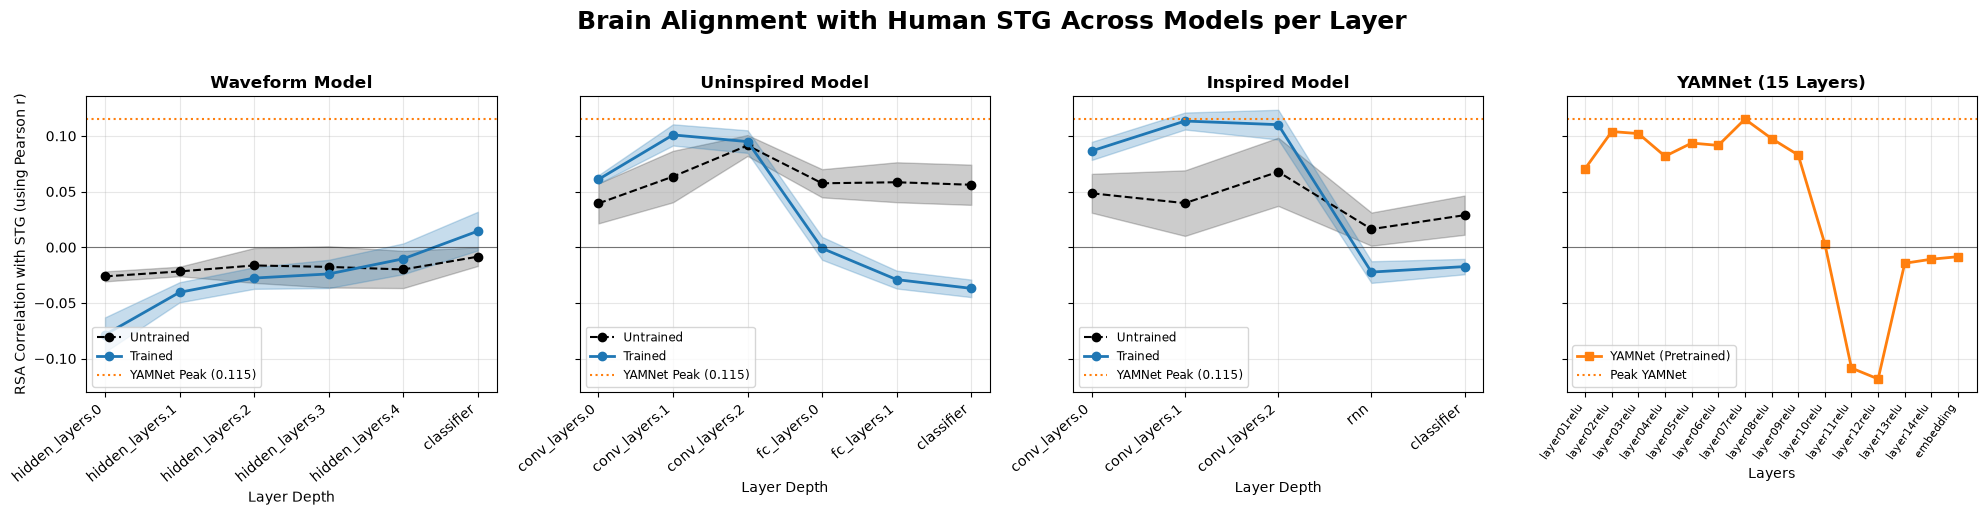

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
yamnet_peak = max(yamnet_alignments.values())

for ax, model_name in zip(axes[:3], MODEL_CLASSES.keys()):
    layers = list(untrained_alignments[model_name].keys())
    x = np.arange(len(layers))

    # Untrained mean & std
    u_mean = np.array([untrained_alignments[model_name][l]["mean"] for l in layers])
    u_std = np.array([untrained_alignments[model_name][l]["std"] for l in layers])

    # Trained mean & std
    t_mean = np.array([trained_alignments[model_name][l]["mean"] for l in layers])
    t_std = np.array([trained_alignments[model_name][l]["std"] for l in layers])

    # Plot Untrained
    ax.plot(x, u_mean, marker="o", linestyle="--", color="black", label="Untrained")
    # Add std visualization
    ax.fill_between(x, u_mean - u_std, u_mean + u_std, color="black", alpha=0.2)

    # Plot Trained
    ax.plot(x, t_mean, marker="o", linewidth=2, color="tab:blue", label="Trained")
    # Add std visualization
    ax.fill_between(x, t_mean - t_std, t_mean + t_std, color="tab:blue", alpha=0.25)

    # Reference lines (strongest yamnet)
    ax.axhline(yamnet_peak, color="tab:orange", linestyle=":", linewidth=1.5, label=f"YAMNet Peak ({yamnet_peak:.3f})")

    # Zero line
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)

    ax.set_title(f"{model_name.capitalize()} Model", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(layers, rotation=40, ha="right")
    ax.set_xlabel("Layer Depth")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left", fontsize=8.5)

# Yamnet across all 15 layers
yam_layers = list(yamnet_alignments.keys())
yam_scores = list(yamnet_alignments.values())
x_yam = np.arange(len(yam_layers))

axes[3].plot(x_yam, yam_scores, marker="s", linewidth=2, color="tab:orange", label="YAMNet (Pretrained)")
axes[3].axhline(yamnet_peak, color="tab:orange", linestyle=":", linewidth=1.5, label=f"Peak YAMNet")
axes[3].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[3].set_title("YAMNet (15 Layers)", fontsize=12, fontweight="bold")
axes[3].set_xticks(x_yam)
axes[3].set_xticklabels(yam_layers, rotation=55, ha="right", fontsize=8)
axes[3].set_xlabel("Layers")
axes[3].grid(alpha=0.3)
axes[3].legend(loc="lower left", fontsize=8.5)
axes[0].set_ylabel("RSA Correlation with STG (using Pearson r)")

plt.suptitle("Brain Alignment with Human STG Across Models per Layer", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

#### Part A. Compare Trained and Untrained Models

Since we already had a first look comparing layers in part C, this time we compare peak alignment across models

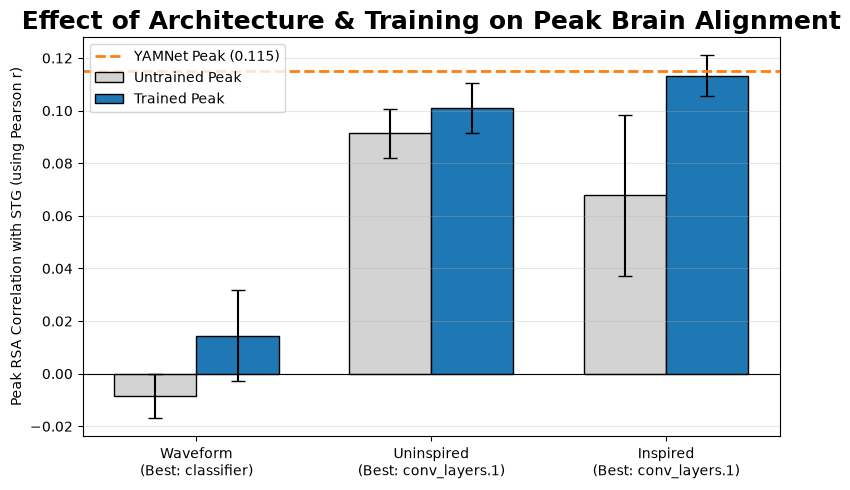

In [24]:
model_names = list(MODEL_CLASSES.keys())
x = np.arange(len(model_names))
width = 0.35

# Find the best layer (with highest mean) for each model in untrained and trained modes
u_peaks, u_stds, u_best_layers = [], [], []
t_peaks, t_stds, t_best_layers = [], [], []

for m in model_names:
    best_u_layer = max(untrained_alignments[m], key=lambda l: untrained_alignments[m][l]["mean"])
    u_peaks.append(untrained_alignments[m][best_u_layer]["mean"])
    u_stds.append(untrained_alignments[m][best_u_layer]["std"])
    u_best_layers.append(best_u_layer)

    best_t_layer = max(trained_alignments[m], key=lambda l: trained_alignments[m][l]["mean"])
    t_peaks.append(trained_alignments[m][best_t_layer]["mean"])
    t_stds.append(trained_alignments[m][best_t_layer]["std"])
    t_best_layers.append(best_t_layer)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width / 2, u_peaks, width, yerr=u_stds, capsize=5, color="lightgray", edgecolor="black", label="Untrained Peak")
ax.bar(x + width / 2, t_peaks, width, yerr=t_stds, capsize=5, color="tab:blue", edgecolor="black", label="Trained Peak")

# YAMNet Peak Reference Line
ax.axhline(yamnet_peak, color="tab:orange", linestyle="--", linewidth=2, label=f"YAMNet Peak ({yamnet_peak:.3f})")
ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels([f"{m.capitalize()}\n(Best: {l})" for m, l in zip(model_names, t_best_layers)])
ax.set_ylabel("Peak RSA Correlation with STG (using Pearson r)")
ax.set_title("Effect of Architecture & Training on Peak Brain Alignment", fontsize=18, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

#### Part B. Effect of architectural choices on brain alignment

TODO

### 3. Vizualization of

In [29]:
# Helper to find the best layer (optionally matching a prefix like 'conv_layers')
def find_peak_layer(alignments_dict: dict, prefix: str = "") -> str:
    matching_layers = [l for l in alignments_dict.keys() if l.startswith(prefix)]
    return max(matching_layers, key=lambda l: alignments_dict[l]["mean"])


# Helper to load activations from the single best run of a trained model
def get_best_run_activations(model_name: str, peak_layer: str) -> dict:
    # Score each run on its peak layer to find the best checkpoint
    runs_list = trained_rdms[model_name]
    run_scores = [compare_rdms(rdm_stg, run[peak_layer]) for run in runs_list]
    best_run_idx = int(np.argmax(run_scores))

    # Load that specific checkpoint file
    files = sorted(Path(CHECKPOINT_DIR).glob(f"{model_name}_run*_best.pt"))
    best_path = files[best_run_idx]

    model = MODEL_CLASSES[model_name](num_classes=NUM_CLASSES).to(device)
    state_dict = torch.load(best_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)

    return extract_activations(santoro_loader, model)


# Find peak layers for each model & YAMNet
best_yamnet_layer = max(yamnet_alignments, key=yamnet_alignments.get)

wave_peak_hidden = find_peak_layer(trained_alignments["waveform"], prefix="hidden_layers")
uninsp_peak_conv = find_peak_layer(trained_alignments["uninspired"], prefix="conv_layers")
uninsp_peak_fc   = find_peak_layer(trained_alignments["uninspired"], prefix="fc_layers")
insp_peak_conv   = find_peak_layer(trained_alignments["inspired"], prefix="conv_layers")

# Extract activations from the best run of each trained model
waveform_acts   = get_best_run_activations("waveform", wave_peak_hidden)
uninspired_acts = get_best_run_activations("uninspired", uninsp_peak_conv)
inspired_acts   = get_best_run_activations("inspired", insp_peak_conv)

# While not much meaningful, we will look at one untrained models for proper comparison
untrained_uninsp_peak = find_peak_layer(untrained_alignments["uninspired"], prefix="conv_layers")
untrained_uninsp_model = MODEL_CLASSES["uninspired"](num_classes=NUM_CLASSES).to(device)
untrained_uninsp_acts = extract_activations(santoro_loader, untrained_uninsp_model)
untrained_insp_peak = find_peak_layer(untrained_alignments["inspired"], prefix="conv_layers")
untrained_insp_model = MODEL_CLASSES["inspired"](num_classes=NUM_CLASSES).to(device)
untrained_insp_acts = extract_activations(santoro_loader, untrained_insp_model)

In [30]:
representations = {
    # Benchmarks & Waveform Baseline
    "Human STG Brain": santoro_dataset.brain_responses.numpy(),
    f"YAMNet Peak ({best_yamnet_layer})": yamnet_activations[best_yamnet_layer],
    f"Waveform Peak ({wave_peak_hidden})": waveform_acts[wave_peak_hidden].numpy(),
    "Waveform (classifier)": waveform_acts["classifier"].numpy(),

    # Uninspired Layers
    f"Uninspired Untrained ({untrained_uninsp_peak})": untrained_uninsp_acts[untrained_uninsp_peak].numpy(),
    f"Uninspired Peak ({uninsp_peak_conv})": uninspired_acts[uninsp_peak_conv].numpy(),
    f"Uninspired FC ({uninsp_peak_fc})": uninspired_acts[uninsp_peak_fc].numpy(),
    "Uninspired (classifier)": uninspired_acts["classifier"].numpy(),

    # Inspired Layers
    f"Inspired Untrained ({untrained_insp_peak})": untrained_insp_acts[untrained_insp_peak].numpy(),
    f"Inspired Peak ({insp_peak_conv})": inspired_acts[insp_peak_conv].numpy(),
    "Inspired (rnn)": inspired_acts["rnn"].numpy(),
    "Inspired (classifier)": inspired_acts["classifier"].numpy(),
}

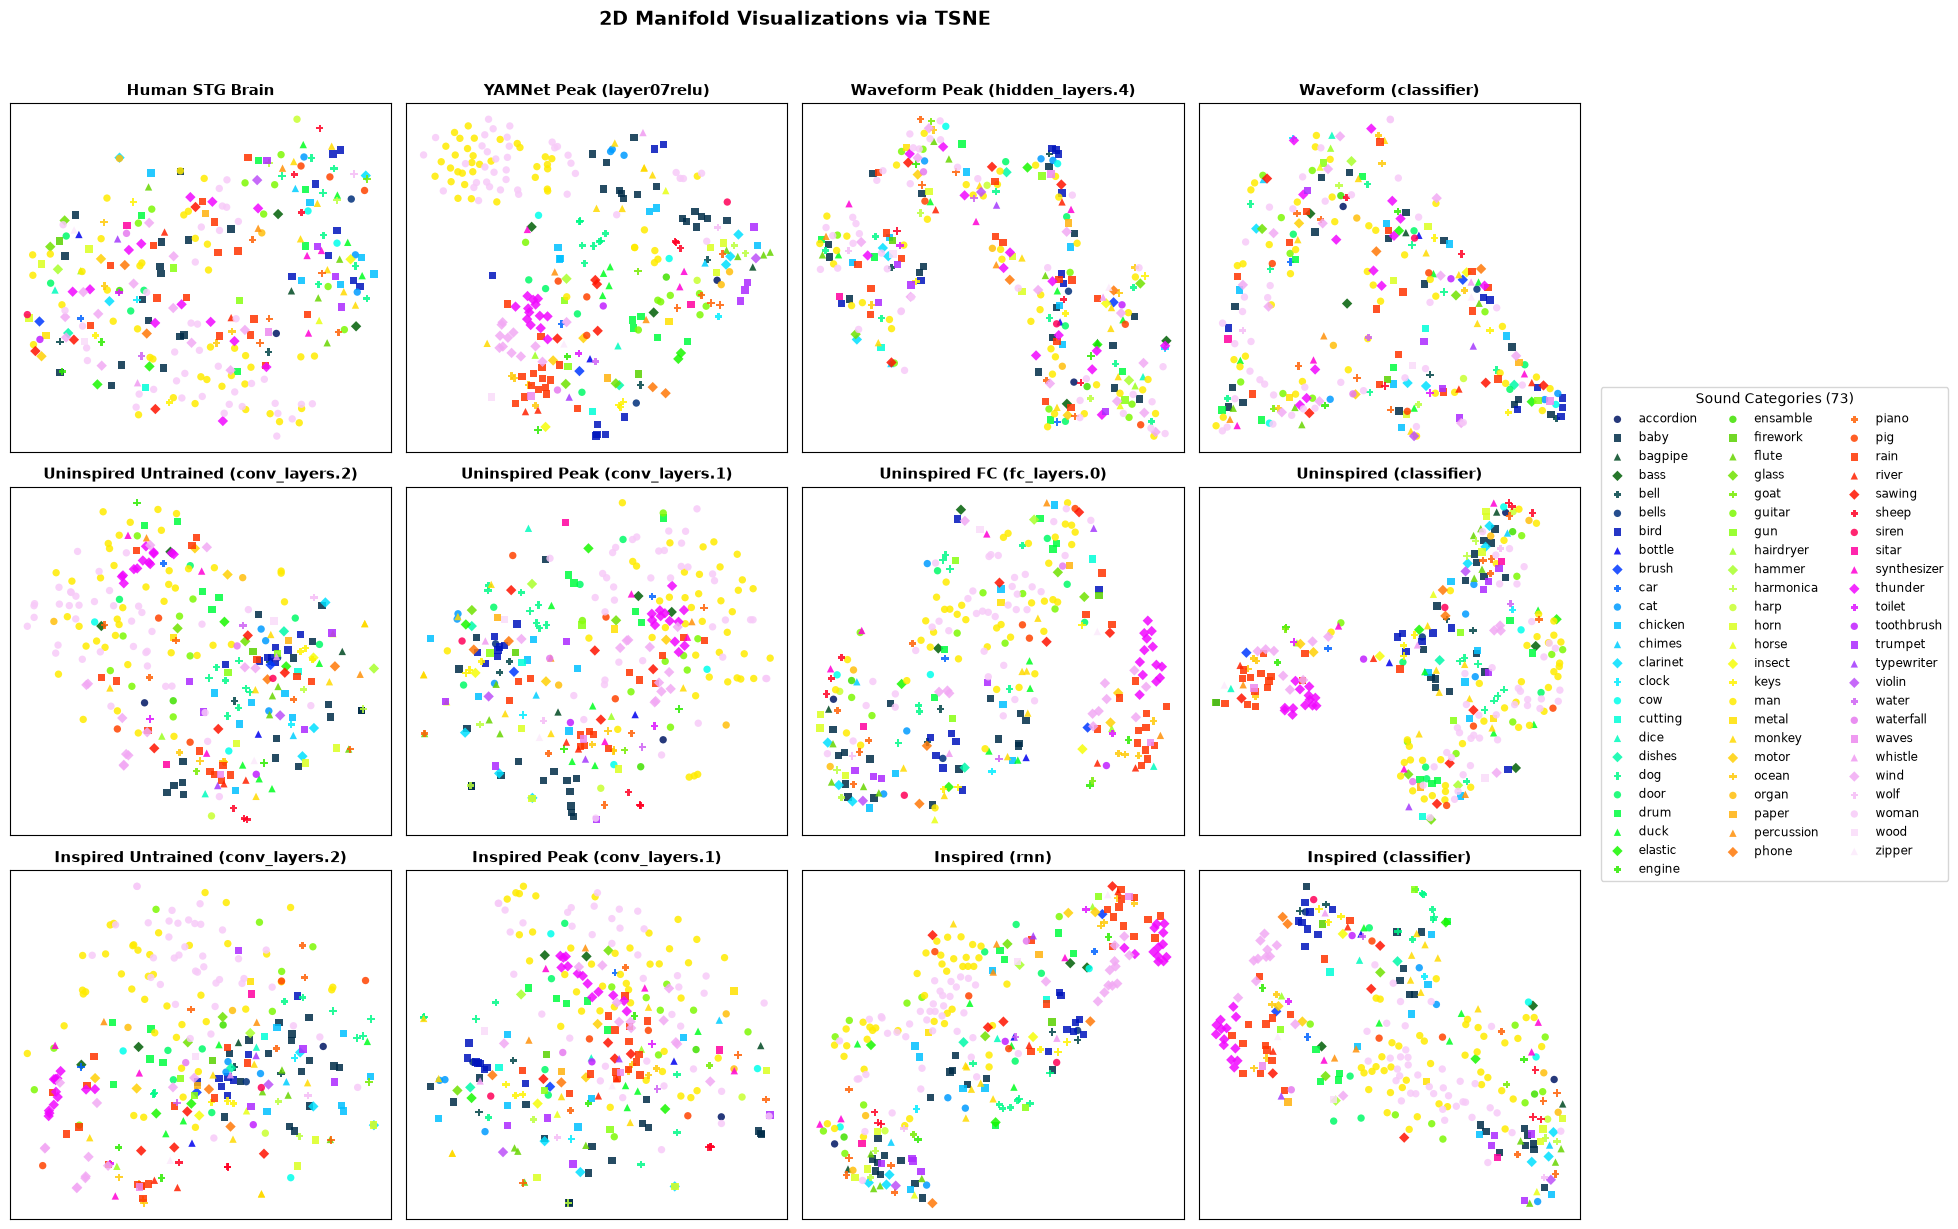

c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio Modelling\Modelling_of_Biological_Systems_Group_11\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\yanra\Documents\Maastricht\Bio 

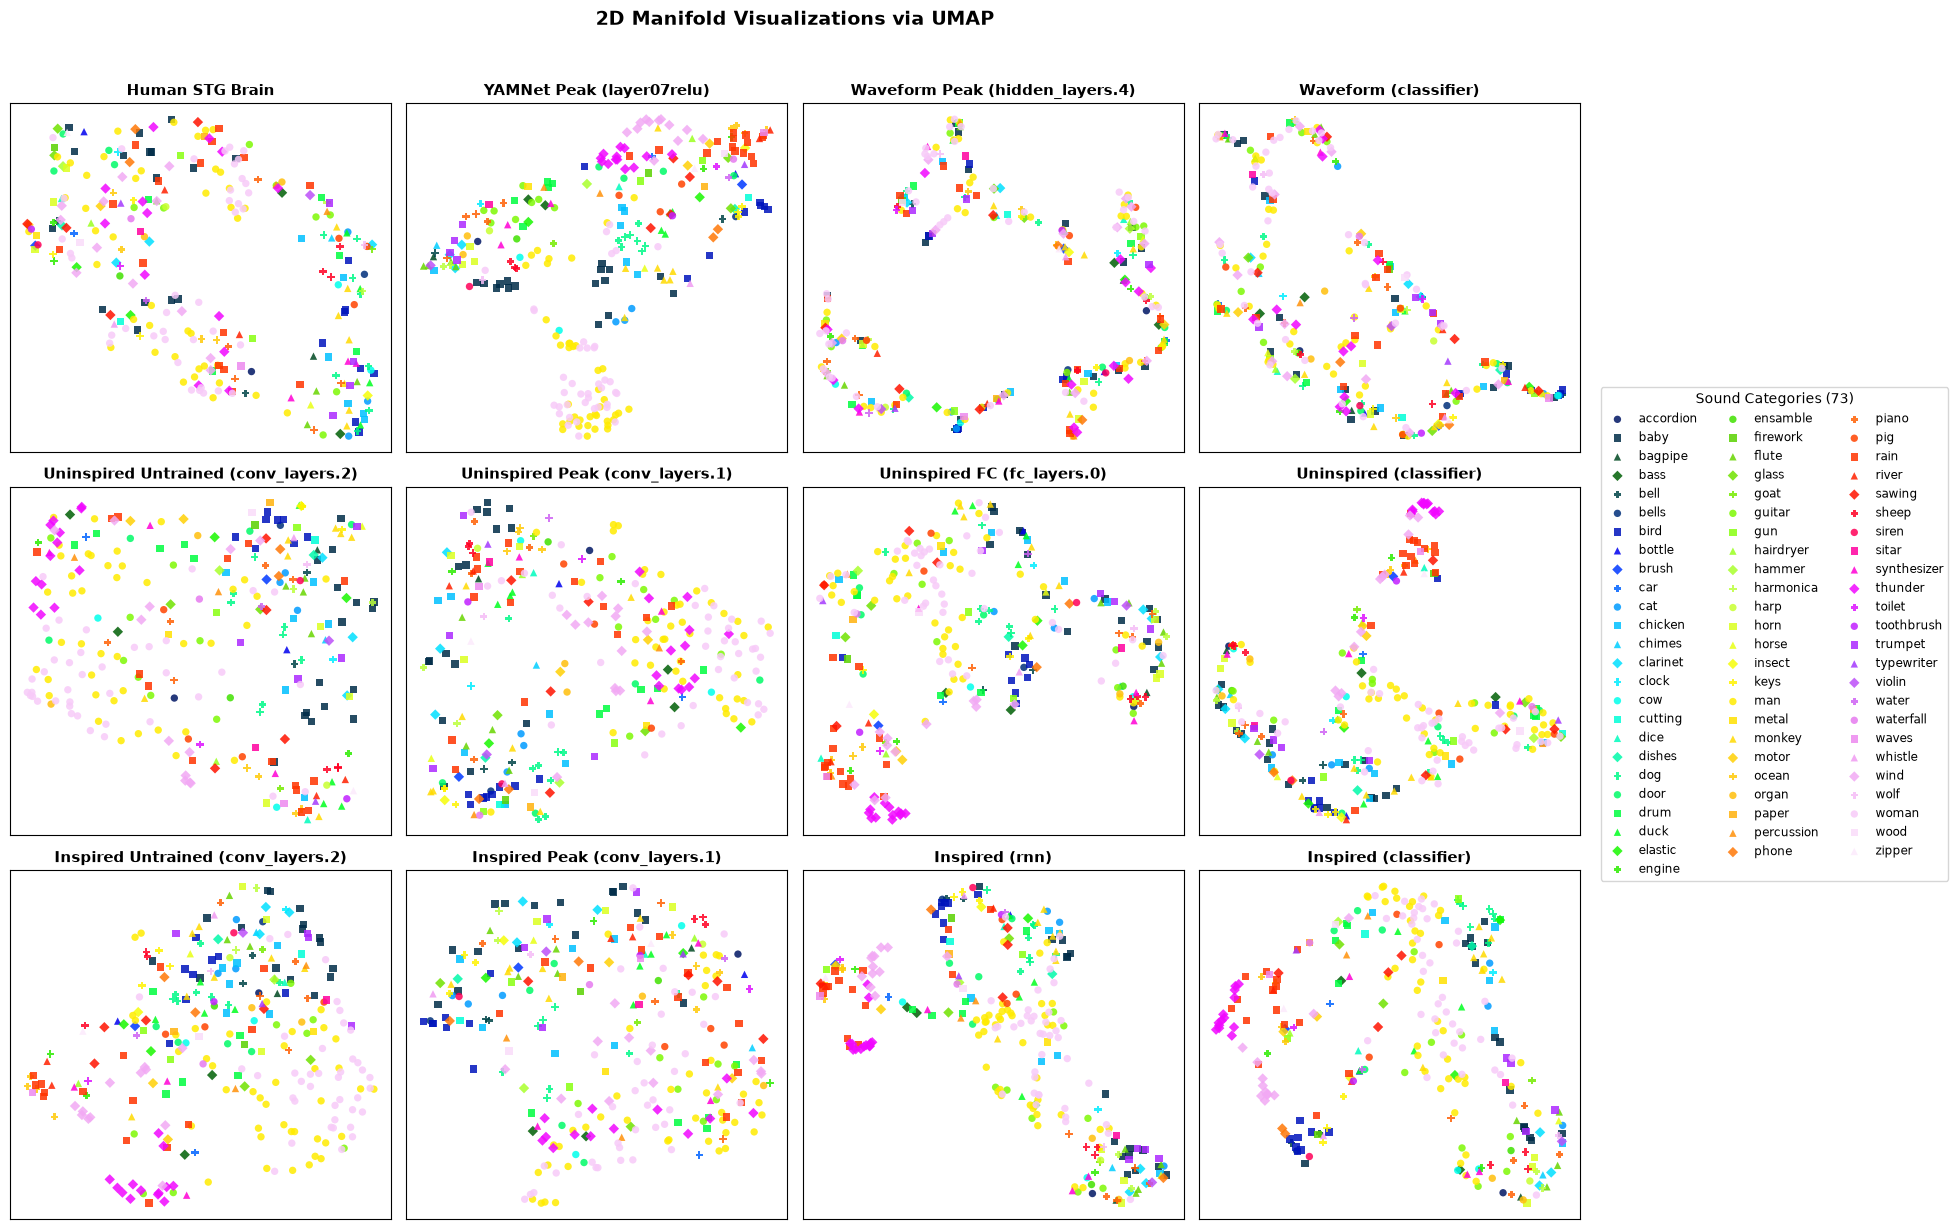

In [38]:
plot_embeddings(representations, np.array(santoro_dataset.categories), method="tsne")
plot_embeddings(representations, np.array(santoro_dataset.categories), method="umap")